# Modelling
- **Dataset**: Crop Recommendation Dataset
- **Source**: Kaggle — Crop Recommendation Dataset
- **Notebook**: 03 — Modelling
- **Authors**: Group E

## Table of Contents

- [0. Outset](#0-outset)
  - [0.1 Imports & Configurations](#01-imports--configurations)
  - [0.2 Data Loading](#02-data-loading)

- [1.0 Logistic Regression](#10-logistic-regression)
  - [1.1 Define Features & Label](#11-define-features--label)
  - [1.2 Split the Dataset](#12-split-the-dataset)
  - [1.3 Feature Scaling](#13-feature-scaling)
  - [1.4 Initializing and Training the Logistic Regression Model](#14-initializing-and-training-the-logistic-regression-model)
  - [1.5 Making Predictions on the Test Dataset](#15-making-predictions-on-the-test-dataset)
  - [1.6 Untuned Logistic Regression Model Evaluation](#16-untuned-logistic-regression-model-evaluation)
  - [1.7 Untuned Logistic Regression Confusion Matrix and Heatmap](#17-untuned-logistic-regression-confusion-matrix-and-heatmap)
  - [1.8 Logistic Regression with Hyperparameter Tuning](#18-logistic-regression-with-hyperparameter-tuning)
  - [1.9 Comparison of Logistic Regression with and without Tuning](#19-comparison-of-logistic-regression-with-and-without-tuning)

- [2.0 SVM](#20-svm)
  - [2.1 Feature Scaling](#21-feature-scaling)
  - [2.2 Initialize and Train SVM](#22-initialize-and-train-svm)
  - [2.3 Prediction and Evaluation](#23-prediction-and-evaluation)
  - [2.4 Untuned SVM Confusion Matrix and Heatmap](#24-untuned-svm-confusion-matrix-and-heatmap)
  - [2.6 SVM with Hyperparameter Tuning](#26-svm-with-hyperparameter-tuning)
  - [2.7 Comparing Results of Tuned vs Untuned SVM](#27-comparing-results-of-tuned-vs-untuned-svm)

- [3.0 Decision Tree](#30-decision-tree)
  - [3.1 Data Preparation & Splitting](#31-data-preparation--splitting)
  - [3.2 Initializing Decision Tree](#32-initializing-decision-tree)
  - [3.3 Prediction and Evaluation](#33-prediction-and-evaluation)
  - [3.4 Untuned Decision Tree Confusion Matrix and Heatmap](#34-untuned-decision-tree-confusion-matrix-and-heatmap)
  - [3.5 Decision Tree with Hyperparameter Tuning](#35-decision-tree-with-hyperparameter-tuning)
  - [3.6 Tuned vs Untuned Decision Tree Model Performance Comparison](#36-tuned-vs-untuned-decision-tree-model-performance-comparison)

- [4.0 Random Forest](#40-random-forest)
  - [4.1 Data Loading and Splitting](#41-data-loading-and-splitting)
  - [4.2 Initialize and Train Random Forest](#42-initialize-and-train-random-forest)
  - [4.3 Predict and Evaluate](#43-predict-and-evaluate)
  - [4.4 Untuned Random Forest Confusion Matrix and Heatmap](#44-untuned-random-forest-confusion-matrix-and-heatmap)
  - [4.5 Untuned Random Forest Feature Importance](#45-untuned-random-forest-feature-importance)
  - [4.6 Random Forest with Hyperparameter Tuning](#46-random-forest-with-hyperparameter-tuning)
  - [4.7 Comparing Tuned vs. Untuned Random Forest Model](#47-comparing-tuned-vs-untuned-random-forest-model)

- [5.0 Comparing Logistic Regression, SVM, Decision Tree and Random Forest Models](#50-comparing-logistic-regression-svm-decision-tree-and-random-forest-models)
  - [5.1 Discussion of Model Comparison Results](#51-discussion-of-model-comparison-results)
  - [5.2 Model Stability with Repeated Stratified CV](#52-model-stability-with-repeated-stratified-cv)
  - [5.3 Error Analysis: Most Frequent Confusions](#53-error-analysis-most-frequent-confusions)
  - [5.4 Permutation Importance (Model-Agnostic)](#54-permutation-importance-model-agnostic)

- [6.0 Multiclass Classification: Top Three Crops Suggestions](#60-multiclass-classification-top-three-crops-suggestions)
  - [6.1 Methodology](#61-methodology)
  - [6.2 Defining the Top Three Recommendations Function](#62-defining-the-top-three-recommendations-function)
  - [6.3 Testing the Results](#63-testing-the-results)
  - [6.4 Calculating the Top 3 Accuracy](#64-calculating-the-top-3-accuracy)
  - [6.5 Discussion of Results](#65-discussion-of-results)


In [ ]:
# Initialize and train the Logistic Regression model
# max_iter is increased because multi-class problems might require more iterations to converge
log_reg_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
log_reg_model.fit(X_train_scaled, y_train)

log_reg_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

# 0 Outset

## 0.1 Imports & Configurations

In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import top_k_accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


## 0.2 Data Loading

In [119]:
# Loading the processed dataset
DATA_PATH = '../data/processed/crop_features_v1.csv'
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"  Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns : {df.columns.tolist()}")
print()
df.head(10)

Dataset loaded successfully.
  Shape   : 2200 rows × 11 columns
  Columns : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'moisture_index', 'P_to_K', 'ph_dev', 'label']



,N,P,K,temperature,humidity,ph,rainfall,moisture_index,P_to_K,ph_dev,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,9.719701,0.976744,0.002985,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,9.809501,1.414634,0.538096,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,9.986483,1.250000,1.340207,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,9.876557,0.875000,0.480401,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,9.973014,1.000000,1.128473,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,9.949010,0.880952,0.573454,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,10.017848,1.447368,0.799194,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,9.906445,1.325000,0.781373,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,9.865338,1.421053,0.185346,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,9.818404,1.526316,0.163746,rice


# 1.0 Logistic Regression

## 1.1 Define Features & Label

In [120]:
# Defining the features (X) and the label (y)
features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 
    'rainfall', 'moisture_index', 'P_to_K', 'ph_dev'
]

X = df[features]
y = df['label']

## 1.2 Split the Dataset

In [121]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 1.3 Feature Scaling

In [122]:
# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1.4 Initializing and Training the Logistic Regression Model 
This is the initial Logistic Regression model without hyperparameters. This model is trained for benchmark purposes against the one with tuned hyperparameters. We will be doing the same (training a model with and without tuned hyperparameters) for all the other machine learning algorithms we use throughout this notebook, to compare the results and arrive at the best performing model.

In [123]:
# Initialize and train the Logistic Regression model
# max_iter is increased because multi-class problems might require more iterations to converge
log_reg_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 1.5 Making Predictions on the Test Dataset

In [124]:
# Make predictions on the test set
y_pred_untuned = log_reg_model.predict(X_test_scaled)

## 1.6 Untuned Logistic Regression Model Evaluation

In [125]:
accuracy = accuracy_score(y_test, y_pred_untuned)
print(f"Accuracy: {accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_untuned))

Accuracy: 98.1818%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      0.95      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90     

## 1.7 Untuned Logistic Regression Confusion Matrix and Heatmap

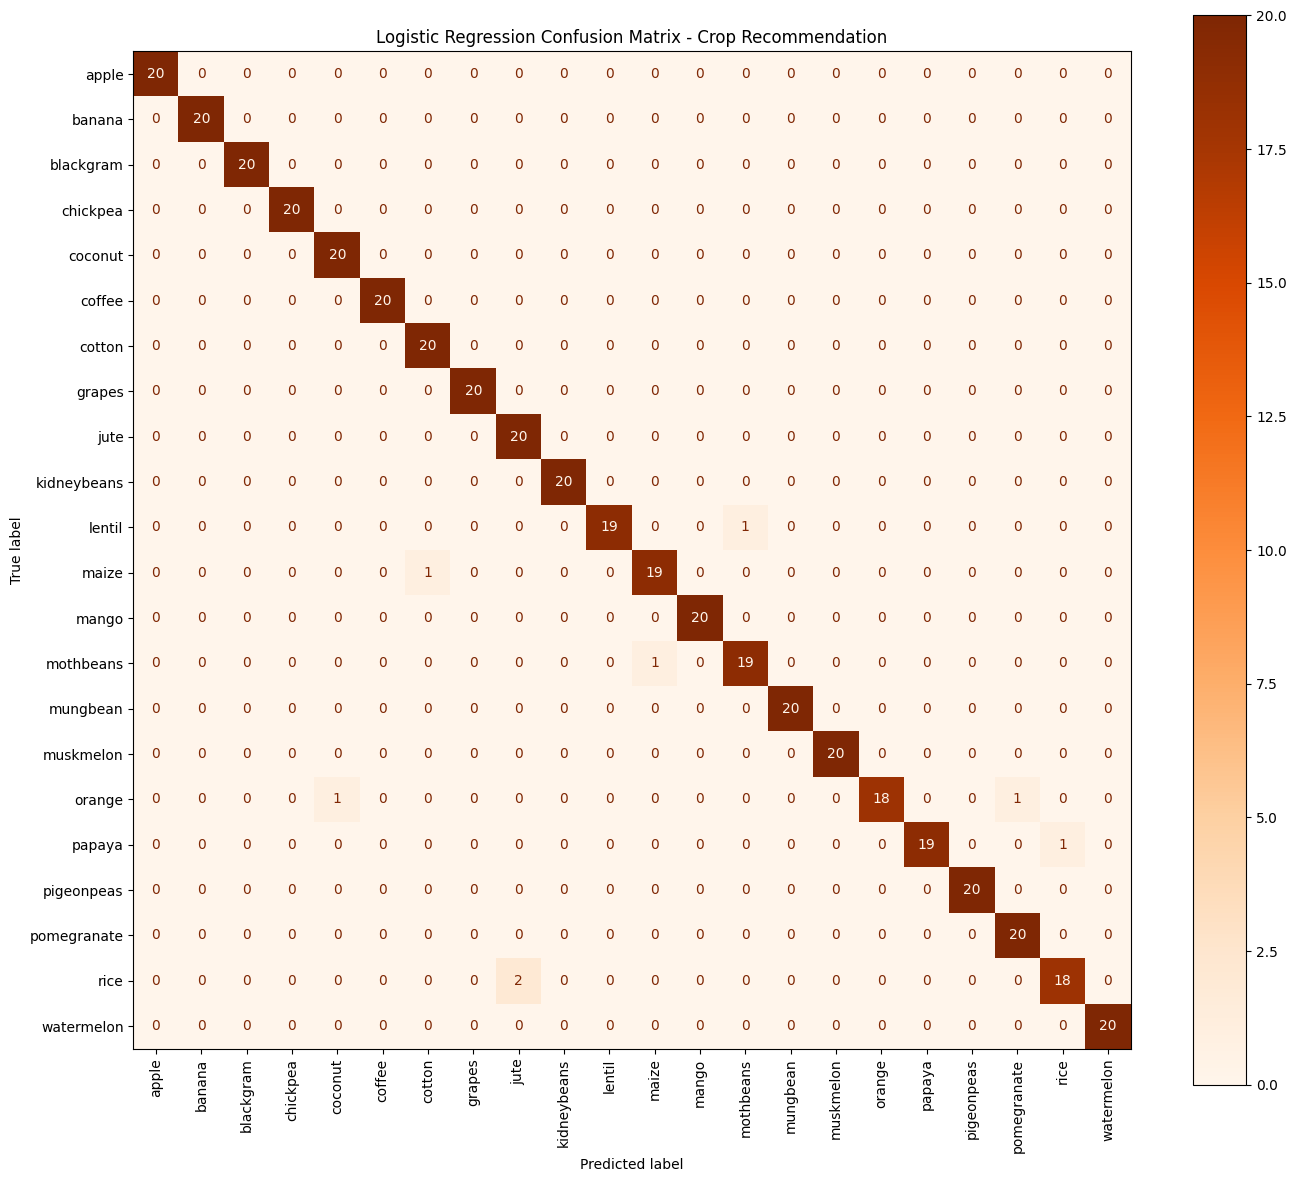

In [126]:
# Remember to use the scaled test data here as well!
y_pred_log = log_reg_model.predict(X_test_scaled)

# Calculate the confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)


# Create the visual heatmap
# Pulling the class labels from the trained Logistic Regression model
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_reg_model.classes_)

# Create a large figure to fit the 22 crop names comfortably
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix. Let's use 'Oranges' to visually distinguish this 
# from the Decision Tree (Blues) and SVM (Greens) plots.
disp_log.plot(cmap='Oranges', ax=ax, xticks_rotation='vertical')

plt.title('Logistic Regression Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()


The matrix is strongly diagonal, showing that Logistic Regression predicts almost all crop classes correctly. The few errors are isolated, so performance is very high overall with only minor confusion between a small number of similar classes.


## 1.8 Logistic Regression with Hyperparameter Tuning 

### 1.8.1 Tuned LR: Define the Hyperparameter Grid

The hyperparameters we are tuning are:

-`C (Regularization Strength)`: This controls how closely the model tries to fit the training data. A lower value (like 0.01) forces a simpler model to prevent overfitting, while a higher value (like 100.0) allows the model to become highly complex.

-`solver`: This is the mathematical algorithm used to find the optimal weights for our features.

-`lbfgs`: The default, generally fast and good for multi-class problems.

-`newton-cg`: A computationally heavier solver that can sometimes find a more precise minimum for the cost function.

-`saga`: Extremely efficient for very large datasets and supports different types of penalties (though we are defaulting to standard L2 here).

-`max_iter`: Some solvers take longer to find the solution. Giving them 2000 or 10000 iterations ensures they don't give up and throw a convergence warning before finishing the math.

In [127]:
# We are testing different combinations of regularization strength and solvers
param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__solver': ['lbfgs', 'newton-cg', 'saga'],
    'clf__max_iter': [2000, 5000, 10000]
}


### 1.8.2 Tuned LR: Initialize the Base Model and GridSearchCV

In [128]:
pipe_log_reg = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42))
    ]
)

# cv=5 means 5-fold cross-validation
# n_jobs=1 is safer in Jupyter/Windows environments
grid_search = GridSearchCV(
    estimator=pipe_log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)


### 1.8.3 Tuned LR: Run Grid Search

In [129]:
# This will train and evaluate a model for every combination of parameters above
print("Starting Grid Search... This may take a moment.\n")
grid_search.fit(X_train, y_train)


Starting Grid Search... This may take a moment.

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.01, 0.1, ...], 'clf__max_iter': [2000, 5000, ...], 'clf__solver': ['lbfgs', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

### 1.8.4 Tuned LR: Extract and Evaluate the Best Model

In [130]:
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing pipeline
best_model = grid_search.best_estimator_

# Test the best model on our unseen test set
y_pred_tuned = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Test Set Accuracy with Best Model: {test_accuracy * 100:.5f}%\n")
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))


Best Hyperparameters Found: {'clf__C': 100.0, 'clf__max_iter': 2000, 'clf__solver': 'newton-cg'}
Best Cross-Validation Accuracy: 98.2386%

Test Set Accuracy with Best Model: 99.09091%

Classification Report (Tuned Model):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.

### 1.8.5 Tuned LR: Confusion Matrix and Heatmap for the Tuned Logistic Regression Model

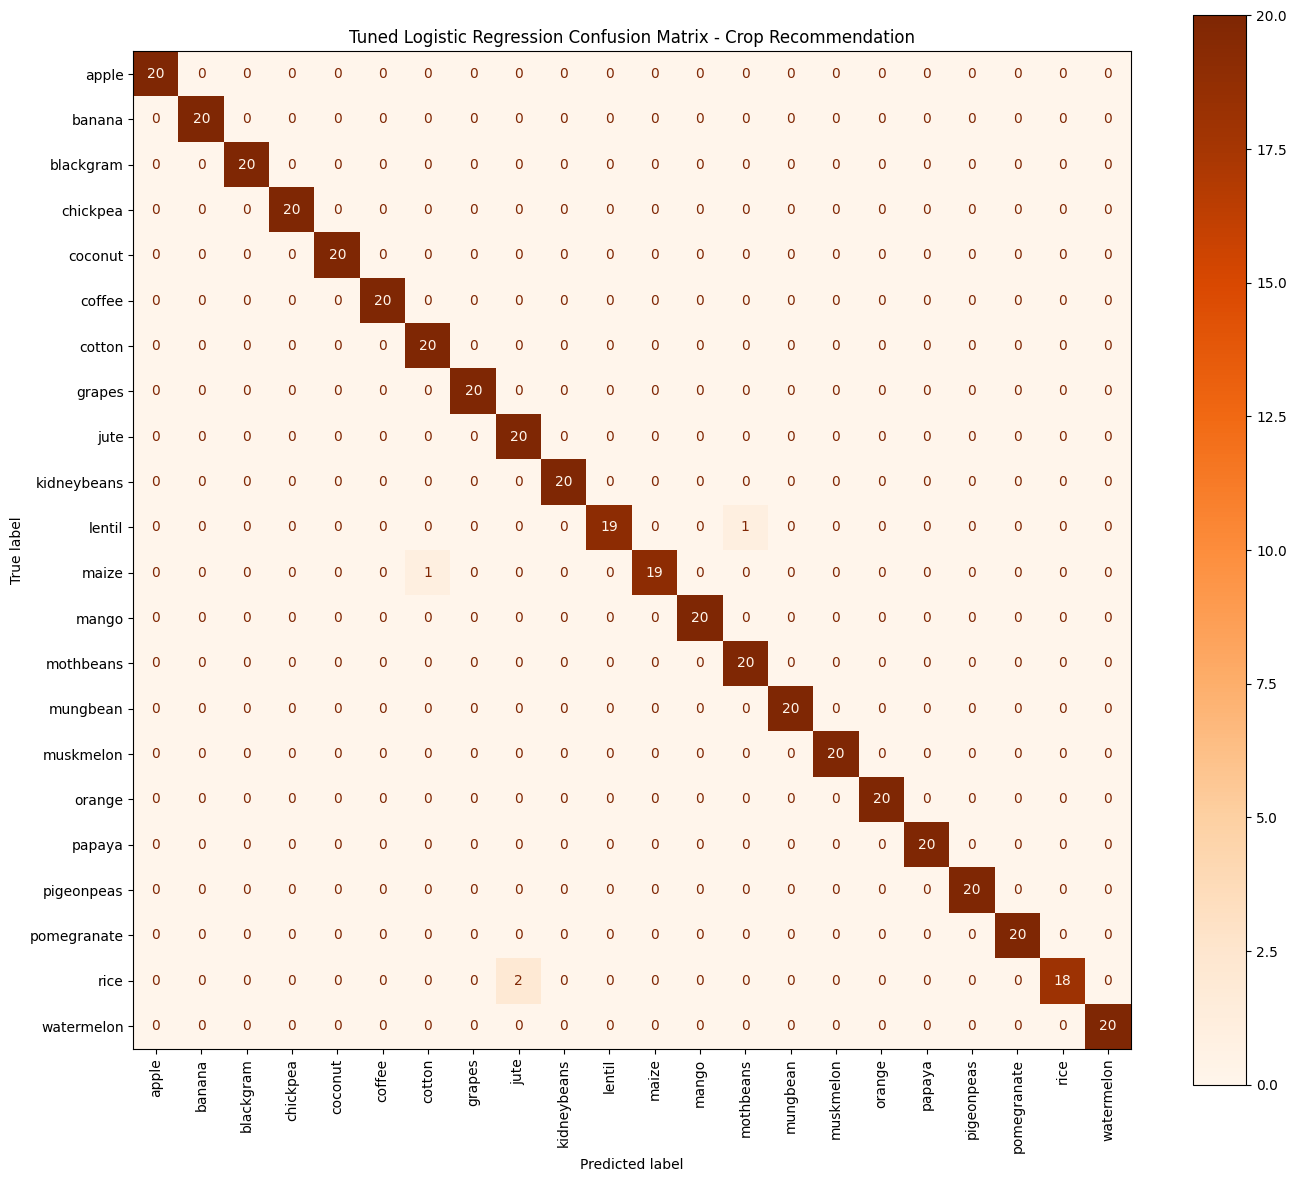

In [131]:
# Calculate the confusion matrix using the tuned predictions
cm_tuned = confusion_matrix(y_test, y_pred_tuned)


# Create the visual heatmap
# We pull the class labels directly from the tuned model
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=best_model.classes_)

# Create a large figure to fit the 22 crop names comfortably
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using 'Oranges' to keep it consistent with the previous Logistic Regression plot
disp_tuned.plot(cmap='Oranges', ax=ax, xticks_rotation='vertical')

plt.title('Tuned Logistic Regression Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()


The tuned confusion matrix remains strongly diagonal, showing that the tuned Logistic Regression also classifies almost all crops correctly. Misclassifications are still very limited, so tuning does not materially change the overall error pattern.

## 1.9 Comparison of Logistic Regression with and without Tuning
Here, though the results are marginal, we can clearly see that the model with hyperparameter tuning performs better.

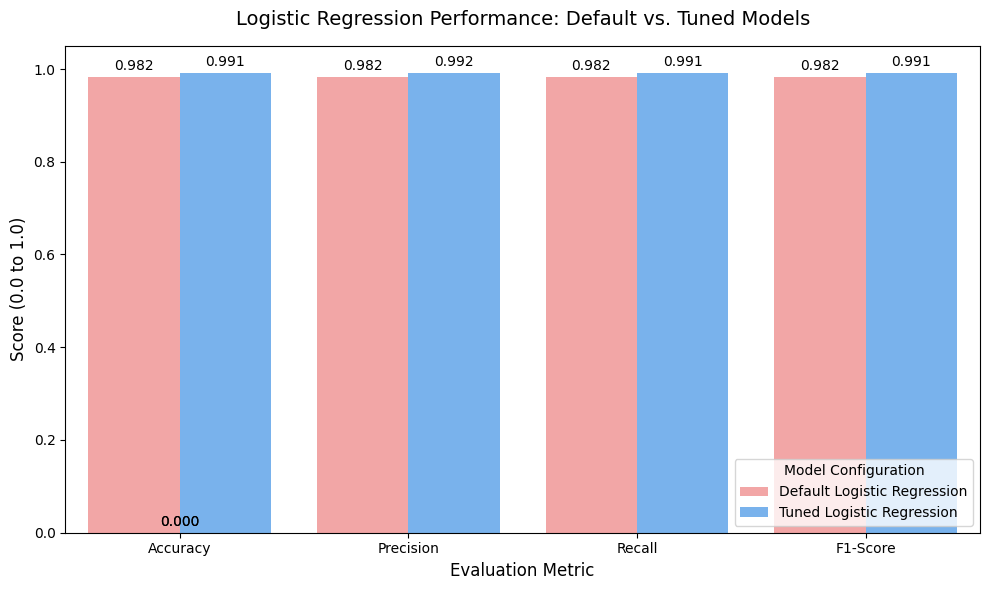

Best parameters found during tuning: {'clf__C': 100.0, 'clf__max_iter': 2000, 'clf__solver': 'newton-cg'}


In [132]:
# We use average='macro' because this is a multi-class dataset. 
# It calculates the metric for each crop independently and finds the unweighted mean.
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0)
    ]

metrics_default = get_metrics(y_test, y_pred_untuned)
metrics_tuned = get_metrics(y_test, y_pred_tuned)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create a DataFrame to easily plot with seaborn
plot_df = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default + metrics_tuned,
    'Model': ['Default Logistic Regression'] * 4 + ['Tuned Logistic Regression'] * 4
})

plt.figure(figsize=(10, 6))

# A grouped bar chart to put the default vs tuned bars right next to each other
sns.barplot(
    data=plot_df, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#FF9999', '#66B2FF'] # Soft red for default, nice blue for tuned
)

# Formatting the chart
plt.title('Logistic Regression Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05) # Give a little headroom above 1.0 for the legend
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact numbers on top of the bars for clarity
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 8), 
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()

print(f"Best parameters found during tuning: {grid_search.best_params_}")

Tuning slightly improves Logistic Regression across all metrics, but the gains are very small. This suggests the default model was already performing strongly, and tuning only provided a marginal improvement.

# 2.0 SVM

## 2.1 Feature Scaling

In [133]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2.2 Initialize and Train SVM

In [134]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## 2.3 Prediction and Evaluation

In [135]:
y_pred_default_svm = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_default_svm)
print(f"Accuracy: {accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_default_svm))

Accuracy: 98.6364%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90     

## 2.4 Untuned SVM Confusion Matrix and Heatmap 

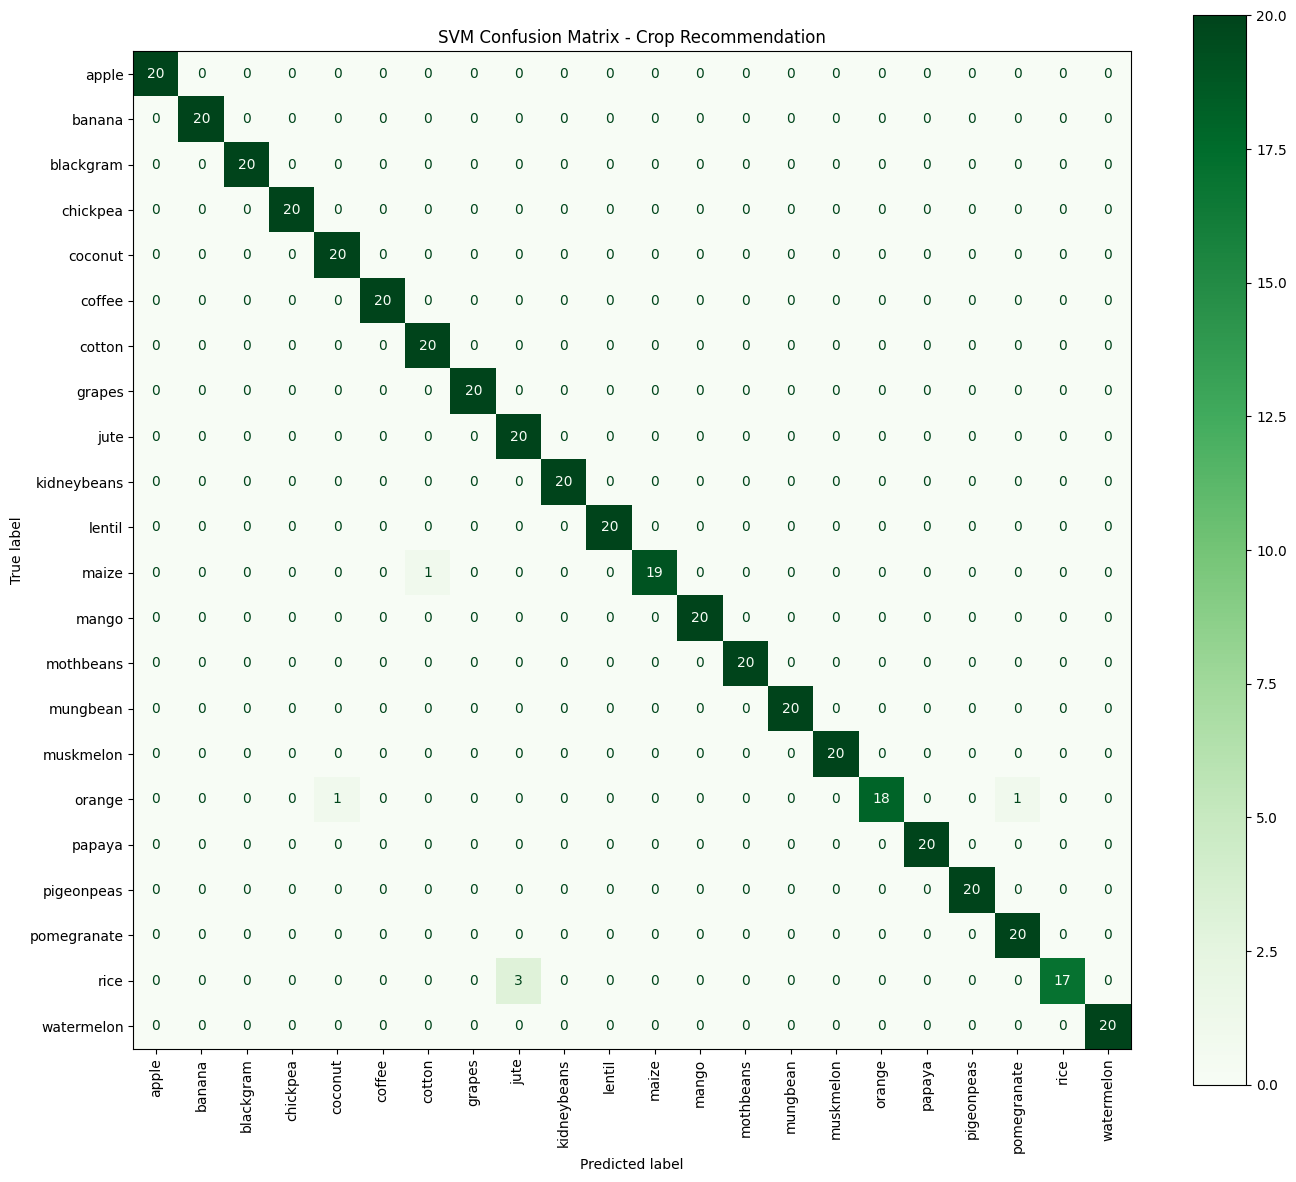

In [136]:
# Generate predictions using the SVM model
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)


# Create the visual heatmap
# We pull the class labels directly from the trained SVM model
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)

# Create a large figure to comfortably fit all 22 crop names
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix
disp_svm.plot(cmap='Greens', ax=ax, xticks_rotation='vertical')

plt.title('SVM Confusion Matrix - Crop Recommendation')
plt.tight_layout() # Keeps the crop labels from getting cut off at the edges
plt.show()


The SVM confusion matrix is highly diagonal, showing very strong classification performance across almost all crop classes. The few errors are isolated, indicating that misclassification is limited to a small number of harder-to-separate crops.

## 2.6 SVM with Hyperparameter Tuning

### 2.6.1 Tuned SVM: Define the Grid

The hyperparameters that we are tuning are:

-`C (Regularization)`: Just like with Logistic Regression, this controls the trade-off between a smooth decision boundary and classifying training points correctly. High C means a strict, complex boundary. Low C means a smoother, more forgiving boundary.

-`kernel`: This determines the shape of the geometric boundary.

-`linear`: Tries to draw flat planes between the crop classes. It is very fast but might fail if the data is highly complex.

-`rbf` (Radial Basis Function): The default. It can wrap around complex clusters of data by projecting them into higher dimensions.

-`gamma`: This is only used by the 'rbf' kernel. It defines how far the influence of a single training point reaches.

A high value (like 0.1) means a point only influences things very close to it, leading to tighter, more jagged boundaries.

A low value (like 0.01) means the point has a broad influence, leading to smoother boundaries. 'scale' and 'auto' are smart defaults that calculate gamma based on your number of features and their variance.

In [137]:
# We are testing different combinations of regularization (C), kernel types, and kernel widths (gamma)
param_grid_svm = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.1, 0.01],
    'clf__kernel': ['rbf', 'linear']
}


### 2.6.2 Tuned SVM: Initialize Base Model

In [138]:
pipe_svm = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=42))
    ]
)

# cv=5 means 5-fold cross-validation
# n_jobs=1 is safer in Jupyter/Windows environments
grid_search_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)


### 2.6.3 Tuned SVM: Run Grid Search

In [139]:
print("Starting SVM Grid Search... Grab a coffee, this might take a minute!\n")
grid_search_svm.fit(X_train, y_train)


Starting SVM Grid Search... Grab a coffee, this might take a minute!

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 1, ...], 'clf__gamma': ['scale', 'auto', ...], 'clf__kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

### 2.6.4 Tuned SVM: Extract and Evaluate Best Model


In [140]:
print(f"\nBest Hyperparameters Found: {grid_search_svm.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_svm.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing pipeline
best_svm_model = grid_search_svm.best_estimator_

# Test the best model on the unseen test set
y_pred_best_svm = best_svm_model.predict(X_test)
test_accuracy_svm = accuracy_score(y_test, y_pred_best_svm)

print(f"Test Set Accuracy with Best SVM: {test_accuracy_svm * 100:.4f}%\n")
print("Classification Report (Tuned SVM):")
print(classification_report(y_test, y_pred_best_svm))



Best Hyperparameters Found: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best Cross-Validation Accuracy: 98.8636%

Test Set Accuracy with Best SVM: 98.8636%

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00 

### 2.6.5 Tuned SVM: Confusion Matrix and Heatmap of Tuned SVM Model


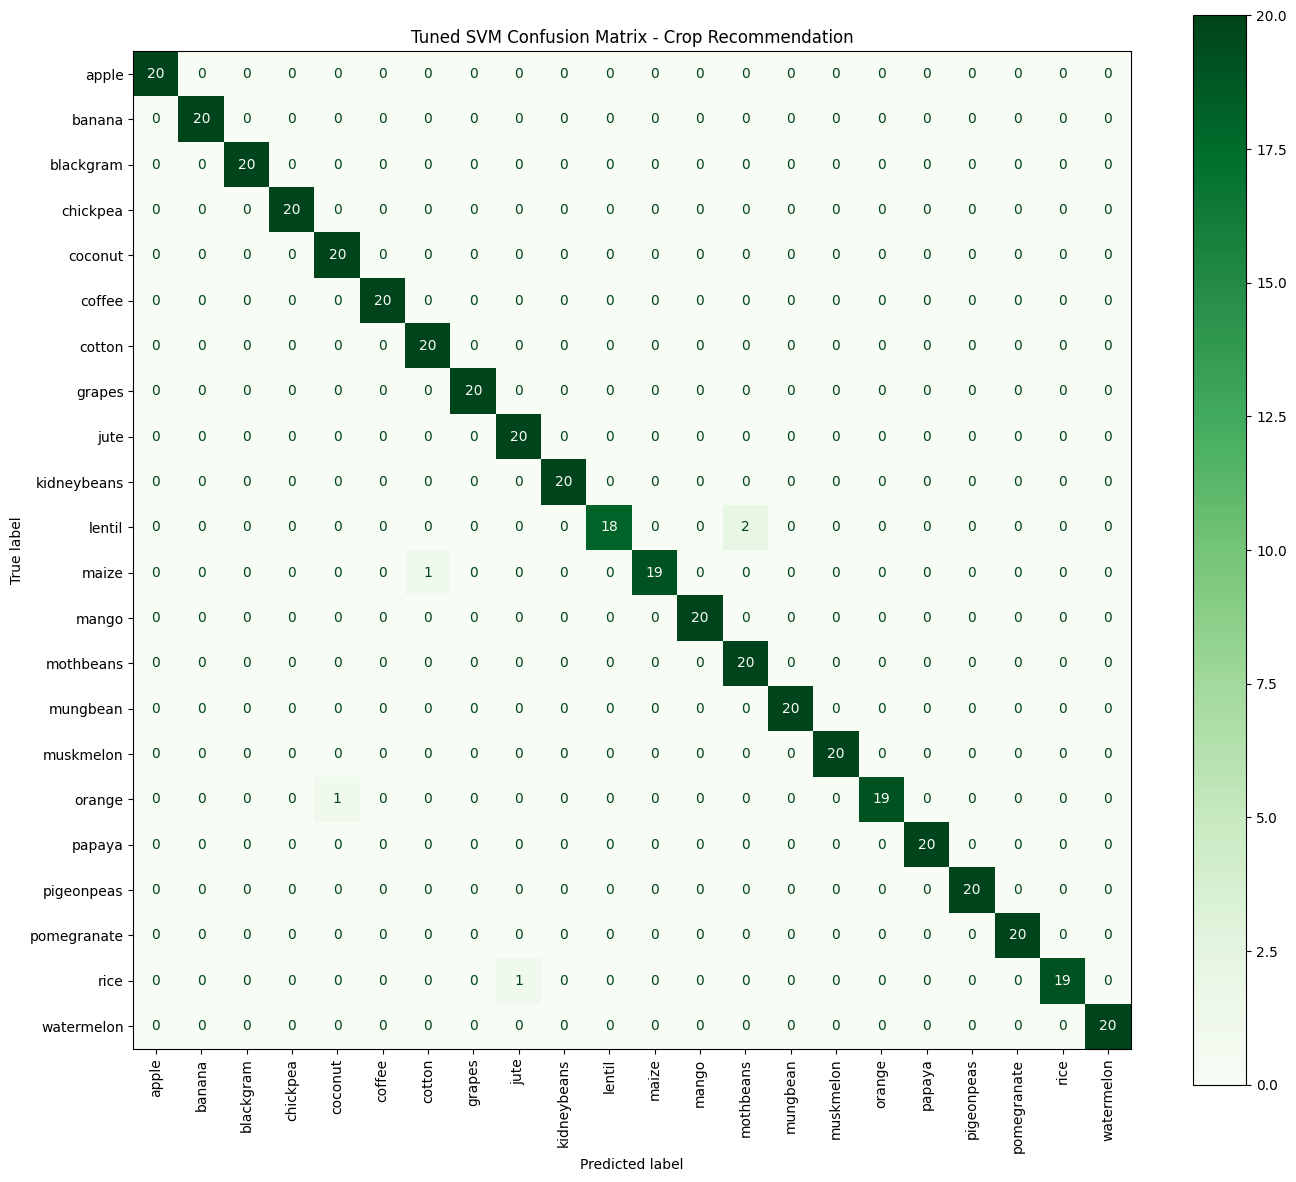

In [141]:
# Calculate the confusion matrix using the tuned predictions
cm_tuned_svm = confusion_matrix(y_test, y_pred_best_svm)


# Create the visual heatmap
# We pull the class labels directly from the tuned model
disp_tuned_svm = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_svm, display_labels=best_svm_model.classes_)

# Create a large figure to comfortably fit all 22 crop names
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using 'Greens' to keep it consistent with the previous SVM plot
disp_tuned_svm.plot(cmap='Greens', ax=ax, xticks_rotation='vertical')

plt.title('Tuned SVM Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()


The tuned SVM confusion matrix is still strongly diagonal, showing excellent performance across nearly all crop classes. Tuning does not meaningfully change the overall error pattern, with only a few isolated misclassifications remaining.

## 2.7 Comparing Results of Tuned vs Untuned SVM
Once again, while the difference is marginal (0.001 to 0.003 difference), the tuned model outperforms the untuned one.

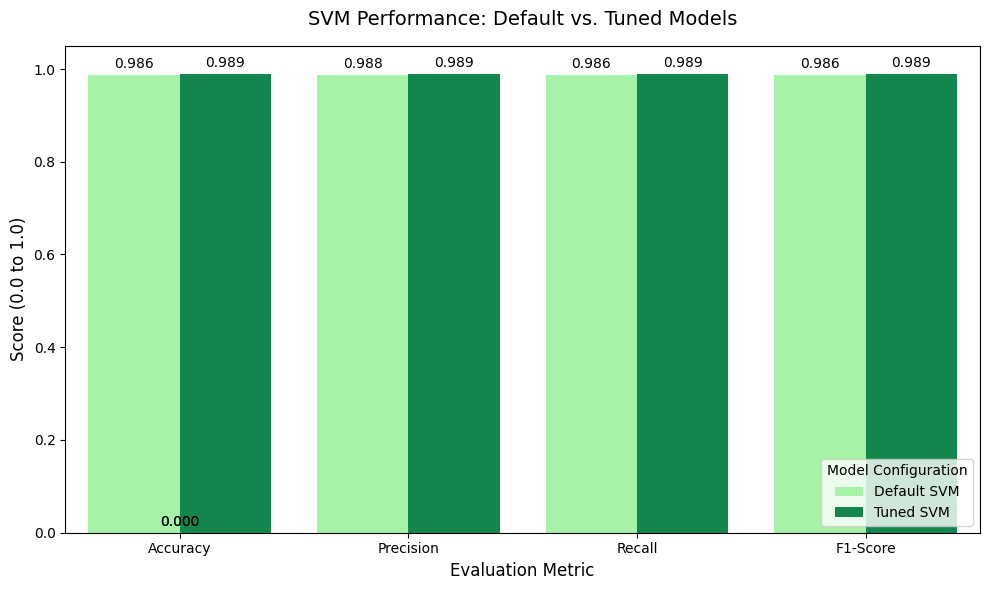

In [142]:
# Calculate metrics for both SVM versions
metrics_default_svm = get_metrics(y_test, y_pred_default_svm)
metrics_tuned_svm = get_metrics(y_test, y_pred_best_svm)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df_svm = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default_svm + metrics_tuned_svm,
    'Model': ['Default SVM'] * 4 + ['Tuned SVM'] * 4
})

plt.figure(figsize=(10, 6))

# Using a green color palette to match your previous SVM heatmap
sns.barplot(
    data=plot_df_svm, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#99FF99', '#00994D'] # Light green for default, bold green for tuned
)

# Formatting the chart
plt.title('SVM Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05) 
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact decimal numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 8), 
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()

Tuning improves SVM slightly across all metrics, but the differences are minimal. This suggests the default SVM was already highly effective, with tuning providing only a small additional gain.

# 3.0 Decision Tree

## 3.1 Data Preparation & Splitting
We intentionally skip the StandardScaler step here

In [143]:
features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 
    'rainfall', 'moisture_index', 'P_to_K', 'ph_dev'
]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3.2 Initializing Decision Tree

In [144]:
# We set max_depth to prevent the tree from growing too complex and overfitting
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

## 3.3 Prediction and Evaluation

In [145]:
y_pred_tree_untuned = tree_model.predict(X_test)

decision_tree_accuracy = accuracy_score(y_test, y_pred_tree_untuned)
print(f"Accuracy: {decision_tree_accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_tree_untuned))

Accuracy: 96.8182%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.65      1.00      0.78        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.85      0.55      0.67        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00     

## 3.4 Untuned Decision Tree Confusion Matrix and Heatmap

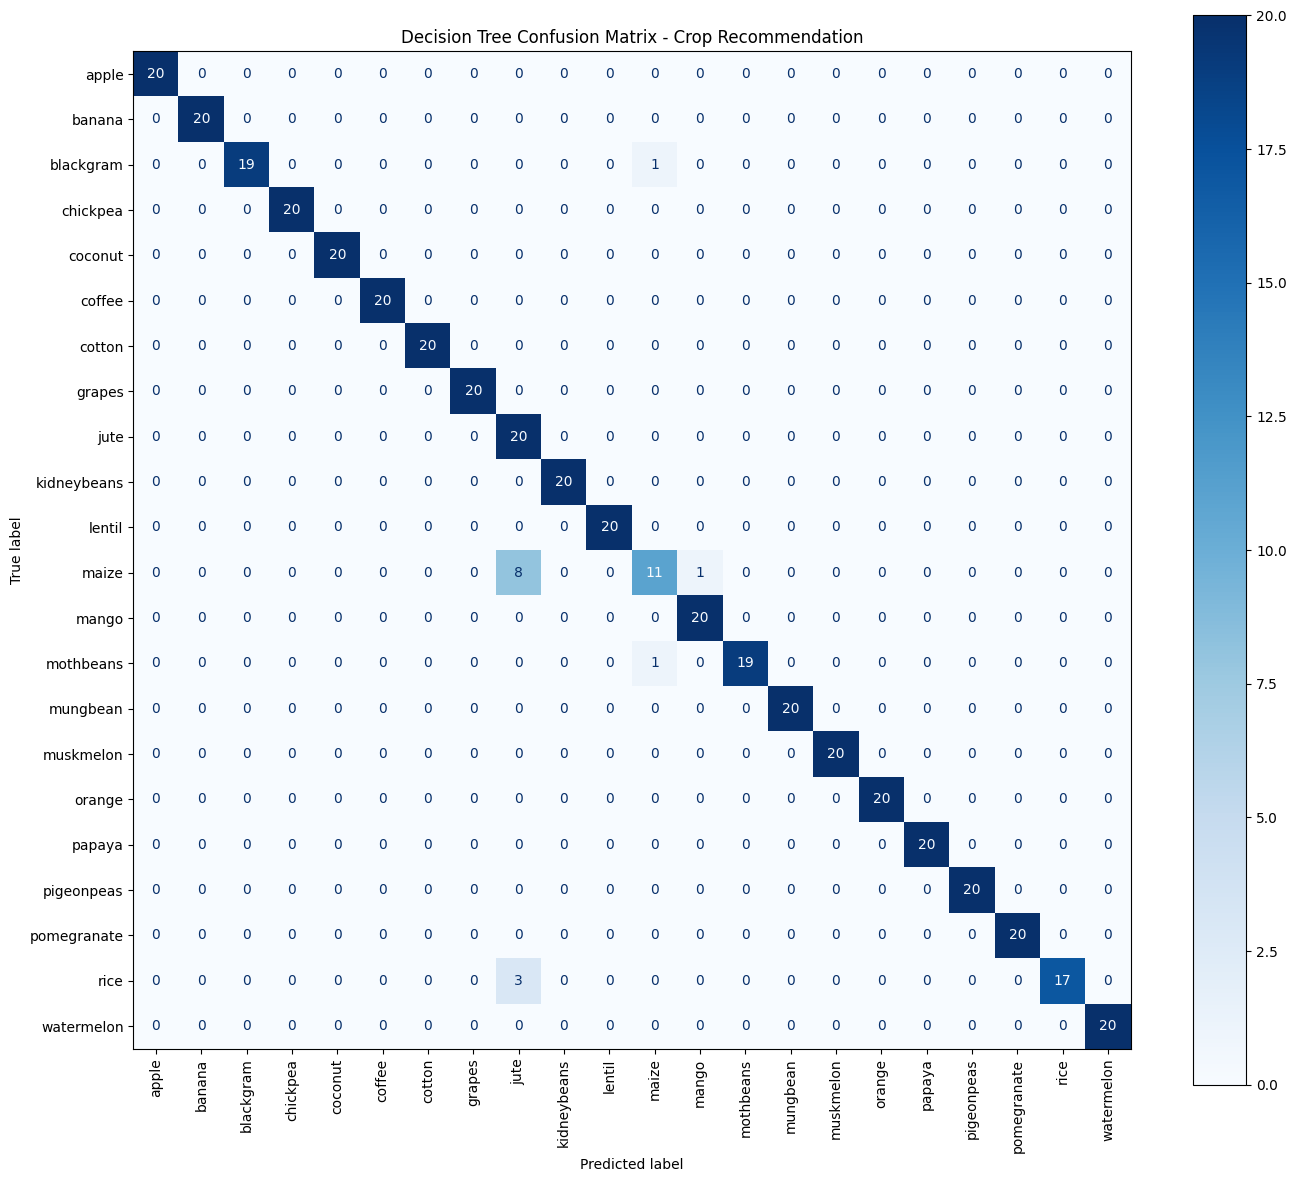

In [146]:
# 1. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_tree_untuned)

# 2. Print the simple text version

# 3. Create a visual heatmap (Highly Recommended for multi-class)
# We use the classes_ attribute from your trained tree_model for the labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)

# Create a large figure so the 22 crop names don't overlap
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using a blue color map, rotating x-labels to make them readable
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title('Decision Tree Confusion Matrix - Crop Recommendation')
plt.tight_layout() # Ensures labels fit within the image
plt.show()


The Decision Tree confusion matrix is mostly diagonal, showing strong overall performance, but with more errors than Logistic Regression and SVM. Misclassifications are concentrated in a few classes, especially maize and rice, suggesting the single tree struggles more with some harder-to-separate crop patterns.


## 3.5 Decision Tree with Hyperparameter Tuning

### 3.5.1 Tuned Decision Tree: Define Grid

The hyperparameters that were chosen to tune are: 
-`criterion`: The function used to measure the quality of a split.

-`gini`: Measures node impurity (the default we used earlier).

-`entropy`: Measures information gain. It involves a slightly more complex calculation (logarithms) but can sometimes yield a more balanced tree.

-`max_depth`: The absolute maximum number of questions the tree can ask before being forced to make a prediction. None allows it to grow infinitely until all leaves are pure, which we balance against the other parameters below.

-`min_samples_split`: The minimum number of data points required to split an internal node. If we set this to 10, a bucket with only 9 crops in it will not be split any further, forcing the tree to stop growing in that direction.

-`min_samples_leaf`: The minimum number of data points required to form a final "leaf" (the final prediction bucket). Setting this to 2 or 4 prevents the tree from creating a highly specific leaf that only caters to a single outlier data point.

In [147]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

### 3.5.2 Tuned Decision Tree: Initialize Base Model and GridSearchCV

In [148]:
base_dt = DecisionTreeClassifier(random_state=42)

# cv=5 means 5-fold cross-validation
# n_jobs=1 is safer in Jupyter/Windows environments
grid_search_dt = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)


### 3.5.3 Tuned Decision Tree: Run Grid Search

In [149]:
print("Starting Decision Tree Grid Search...\n")
grid_search_dt.fit(X_train, y_train)

Starting Decision Tree Grid Search...

Fitting 5 folds for each of 90 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

### 3.5.4 Tuned Decision Tree: Extract and Evaluate Best Model

In [150]:
print(f"Best Hyperparameters Found: {grid_search_dt.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_dt.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing model
best_dt_model = grid_search_dt.best_estimator_

# Test the best model on the unseen test set
y_pred_best_dt = best_dt_model.predict(X_test)
test_accuracy_dt = accuracy_score(y_test, y_pred_best_dt)

print(f"Test Set Accuracy with Best Decision Tree: {test_accuracy_dt * 100:.4f}%\n")
print("Classification Report (Tuned Decision Tree):")
print(classification_report(y_test, y_pred_best_dt))

Best Hyperparameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-Validation Accuracy: 98.3523%

Test Set Accuracy with Best Decision Tree: 98.6364%

Classification Report (Tuned Decision Tree):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.90      0.95      0.93        20
       mango       0.95      1.00      0.

### 3.5.5 Tuned Decision Tree: Confusion Matrix and Heatmap for Tuned Decision Tree

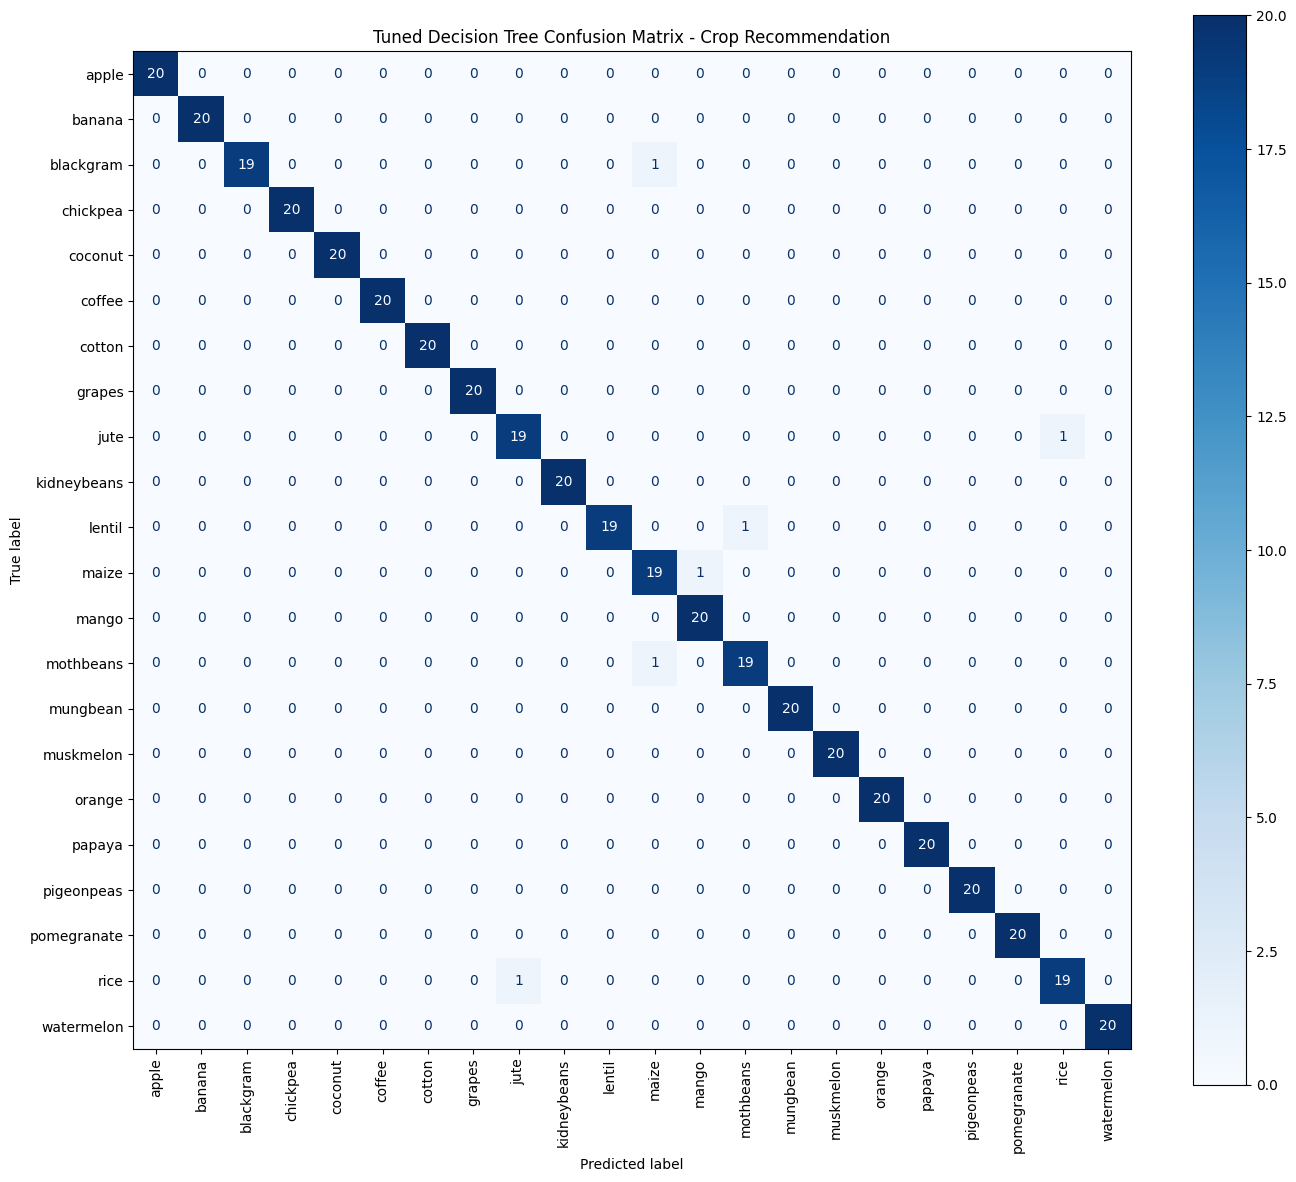

In [151]:
# Plot the confusion matrix
cm_tuned_dt = confusion_matrix(y_test, y_pred_best_dt)


disp_tuned_dt = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_dt, display_labels=best_dt_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))

# Keeping the 'Blues' colormap for consistency
disp_tuned_dt.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title('Tuned Decision Tree Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()


The tuned Decision Tree confusion matrix is more strongly diagonal, showing that tuning reduced several of the earlier misclassifications. Errors are now limited and isolated, suggesting the tuned model generalizes better than the default tree.

## 3.6 Tuned vs Untuned Decision Tree Model Performance Comparison
The tuned Decision Tree model decisively performs better than its untuned counterpart, moreso than the previous models.

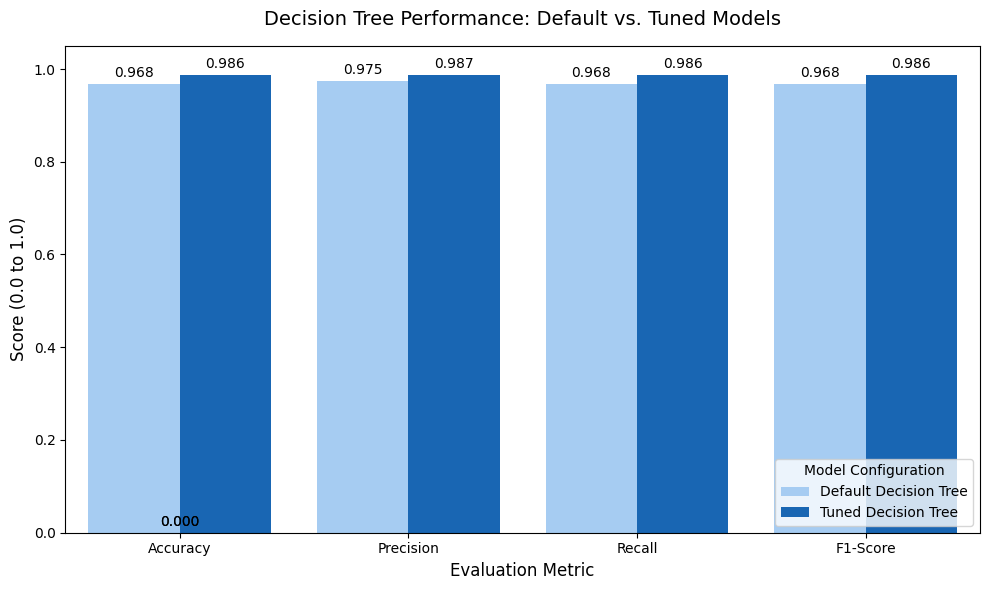

In [152]:
# Calculate metrics for both Decision Tree versions
metrics_default_dt = get_metrics(y_test, y_pred_tree_untuned)
metrics_tuned_dt = get_metrics(y_test, y_pred_best_dt)

# --- STEP 4: Prepare Data for the Bar Chart ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df_dt = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default_dt + metrics_tuned_dt,
    'Model': ['Default Decision Tree'] * 4 + ['Tuned Decision Tree'] * 4
})

# --- STEP 5: Plot the Bar Chart Comparison ---
plt.figure(figsize=(10, 6))

# Using a blue color palette to match your original Decision Tree heatmap
sns.barplot(
    data=plot_df_dt,
    x='Metric',
    y='Score',
    hue='Model',
    palette=['#99CCFF', '#0066CC'] # Light blue for default, dark blue for tuned
)

plt.title('Decision Tree Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05)
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact decimal numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 8),
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()


Tuning improves the Decision Tree across all metrics by a noticeable margin, unlike Logistic Regression and SVM where gains were minimal. This suggests tree performance is more sensitive to hyperparameter settings, and tuning helped reduce overfitting and improve generalization.

# 4.0 Random Forest

## 4.1 Data Loading and Splitting

In [153]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4.2 Initialize and Train Random Forest

In [154]:
# n_estimators is the number of trees in the forest.
# n_jobs=1 keeps execution stable in environments that restrict process spawning.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=1)
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 4.3 Predict and Evaluate

In [155]:
y_pred_rf_untuned = rf_model.predict(X_test)

rf_untuned_accuracy = accuracy_score(y_test, y_pred_rf_untuned)
print(f"Accuracy: {rf_untuned_accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf_untuned))

Accuracy: 99.5455%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00     

## 4.4 Untuned Random Forest Confusion Matrix and Heatmap


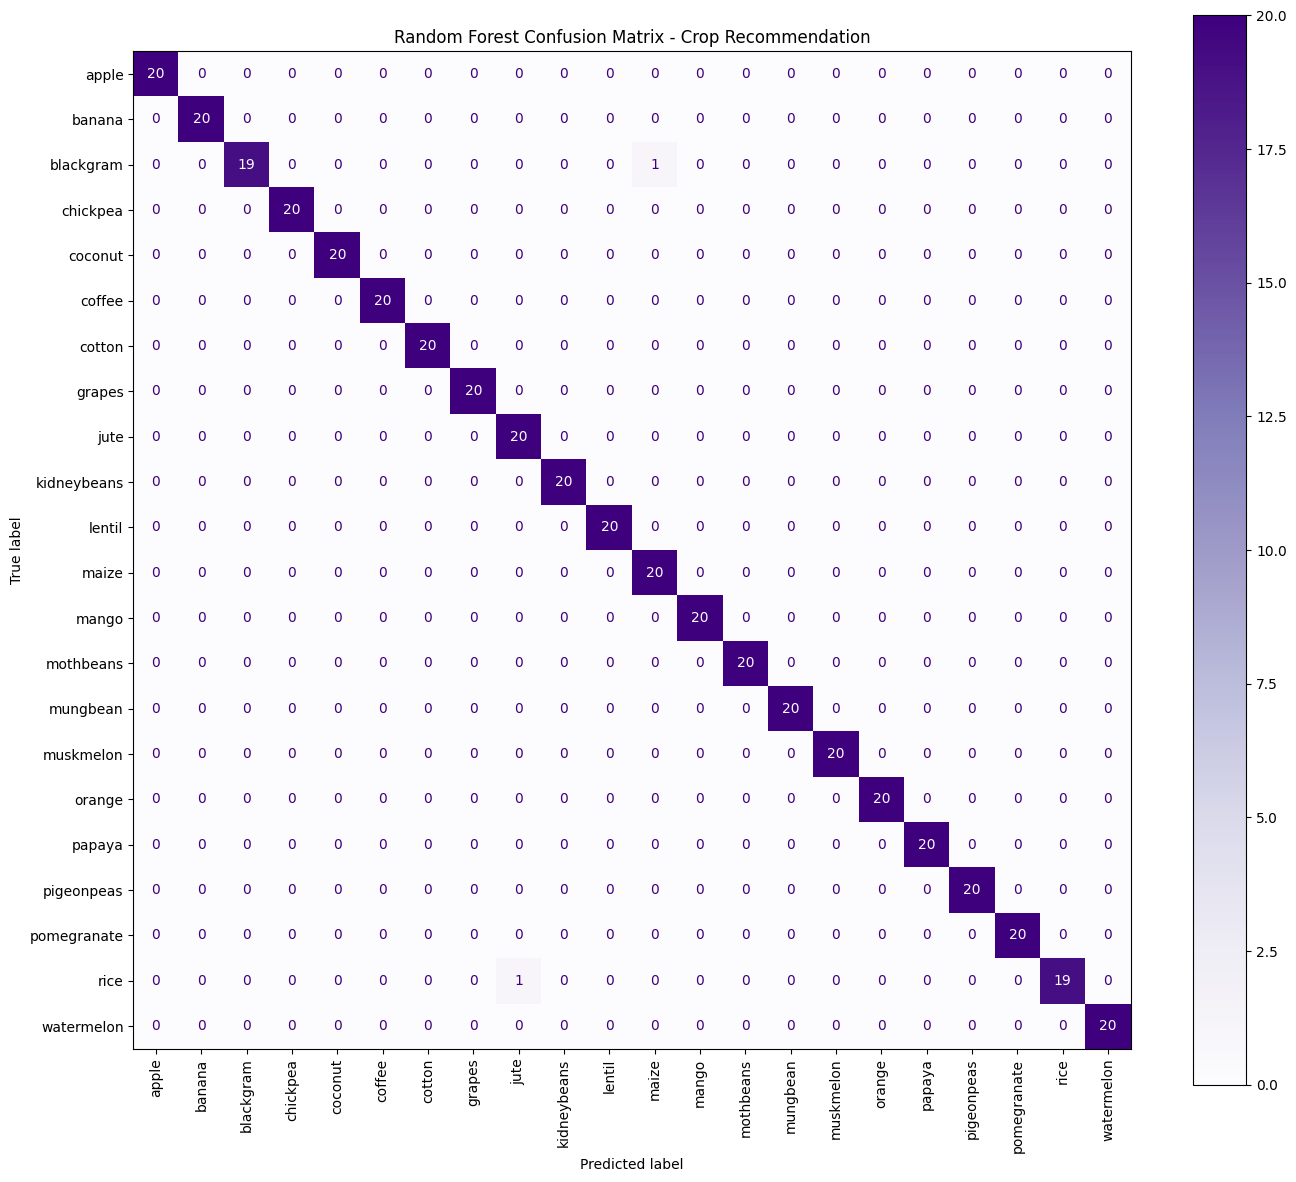

In [156]:
cm_rf = confusion_matrix(y_test, y_pred_rf_untuned)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
# Using 'Purples' to distinguish from Logistic (Oranges), SVM (Greens), and Decision Tree (Blues)
disp_rf.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')

plt.title('Random Forest Confusion Matrix - Crop Recommendation')
plt.tight_layout()
plt.show()

The Random Forest confusion matrix is almost perfectly diagonal, indicating near-perfect classification across crop classes. Only a couple of isolated errors remain, showing that the model handles class separation extremely well.

## 4.5 Untuned Random Forest Feature Importance


Feature Importances:
       Feature  Importance
      humidity    0.179694
      rainfall    0.159675
             K    0.144369
moisture_index    0.138460
             P    0.122959
             N    0.092118
        P_to_K    0.076887
   temperature    0.045569
            ph    0.027953
        ph_dev    0.012317




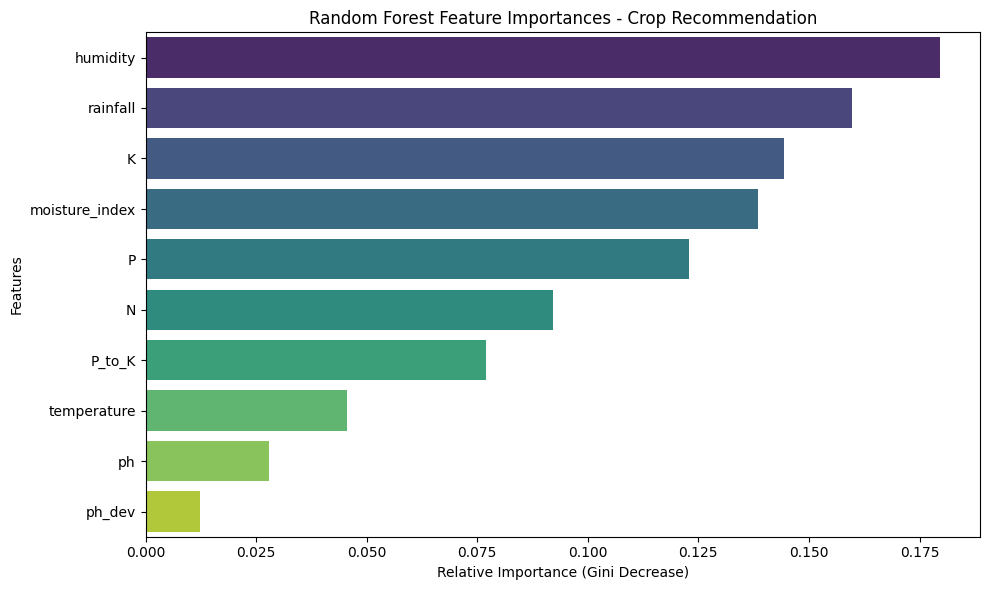

In [157]:
importances = rf_model.feature_importances_

# Create a DataFrame for easy sorting and plotting 
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort the features from most to least important 
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the exact numerical values for reference
print("Feature Importances:")
print(feature_importance_df.to_string(index=False))
print("\n")

# Plot the Feature Importances
plt.figure(figsize=(10, 6))

# We use a horizontal bar chart (x='Importance', y='Feature') because it makes 
# the feature names much easier to read without overlapping.
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)

plt.title('Random Forest Feature Importances - Crop Recommendation')
plt.xlabel('Relative Importance (Gini Decrease)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

The feature importance results show that humidity, rainfall, and potassium are the strongest predictors, while moisture_index also ranks highly, supporting the value of the engineered features. In contrast, ph and ph_dev contribute much less, suggesting that not all engineered or original variables are equally informative for Random Forest.

## 4.6 Random Forest with Hyperparameter Tuning

### 4.6.1 Tuned Random Forest: Define the Hyperparameter Grid

The hyperparameters we are tuning are:
-`n_estimators`: This is the total number of Decision Trees in the forest.

-50 trains quickly but might have slightly less voting power.

-200 gives the forest exceptional robust voting power to cancel out individual tree errors, but it takes four times as long to train.

-`max_depth`: Just like with the single Decision Tree, this limits how many sequential questions a tree can ask. By testing 10, 15, 20, and None (unlimited), we can find the sweet spot between capturing complex crop relationships and preventing the trees from over-memorizing the data.

-`min_samples_split`: This dictates the minimum number of data points a bucket needs to have before it is allowed to split again. A higher number (like 10) forces the individual trees to be simpler and broader.

In [158]:
# We are testing the number of trees, their maximum depth, and how they split
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

### 4.6.2 Tuned Random Forest: Initialize Base Model and GridSearchCV

In [159]:
base_rf = RandomForestClassifier(random_state=42, n_jobs=1)

# cv=5 means 5-fold cross-validation
# n_jobs=1 is safer in Jupyter/Windows environments
# verbose=1 gives progress updates
grid_search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)


### 4.6.3 Tuned Random Forest: Run Grid Search

In [160]:
print("Starting Random Forest Grid Search... This will train thousands of trees!\n")
grid_search_rf.fit(X_train, y_train)

Starting Random Forest Grid Search... This will train thousands of trees!

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

### 4.6.4 Tuned Random Forest: Extract and Evaluate Best Model

In [161]:
print(f"\nBest Hyperparameters Found: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_rf.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing model
best_rf_model = grid_search_rf.best_estimator_

# Test the best model on the unseen test set
y_pred_best_rf = best_rf_model.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_pred_best_rf)

print(f"Test Set Accuracy with Best Random Forest: {test_accuracy_rf * 100:.4f}%\n")
print("Classification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_best_rf))


Best Hyperparameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Accuracy: 99.3750%

Test Set Accuracy with Best Random Forest: 99.3182%

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbe

### 4.6.5 Tuned Random Forest: Confusion Matrix and Heatmap of Tuned Random Forest Model

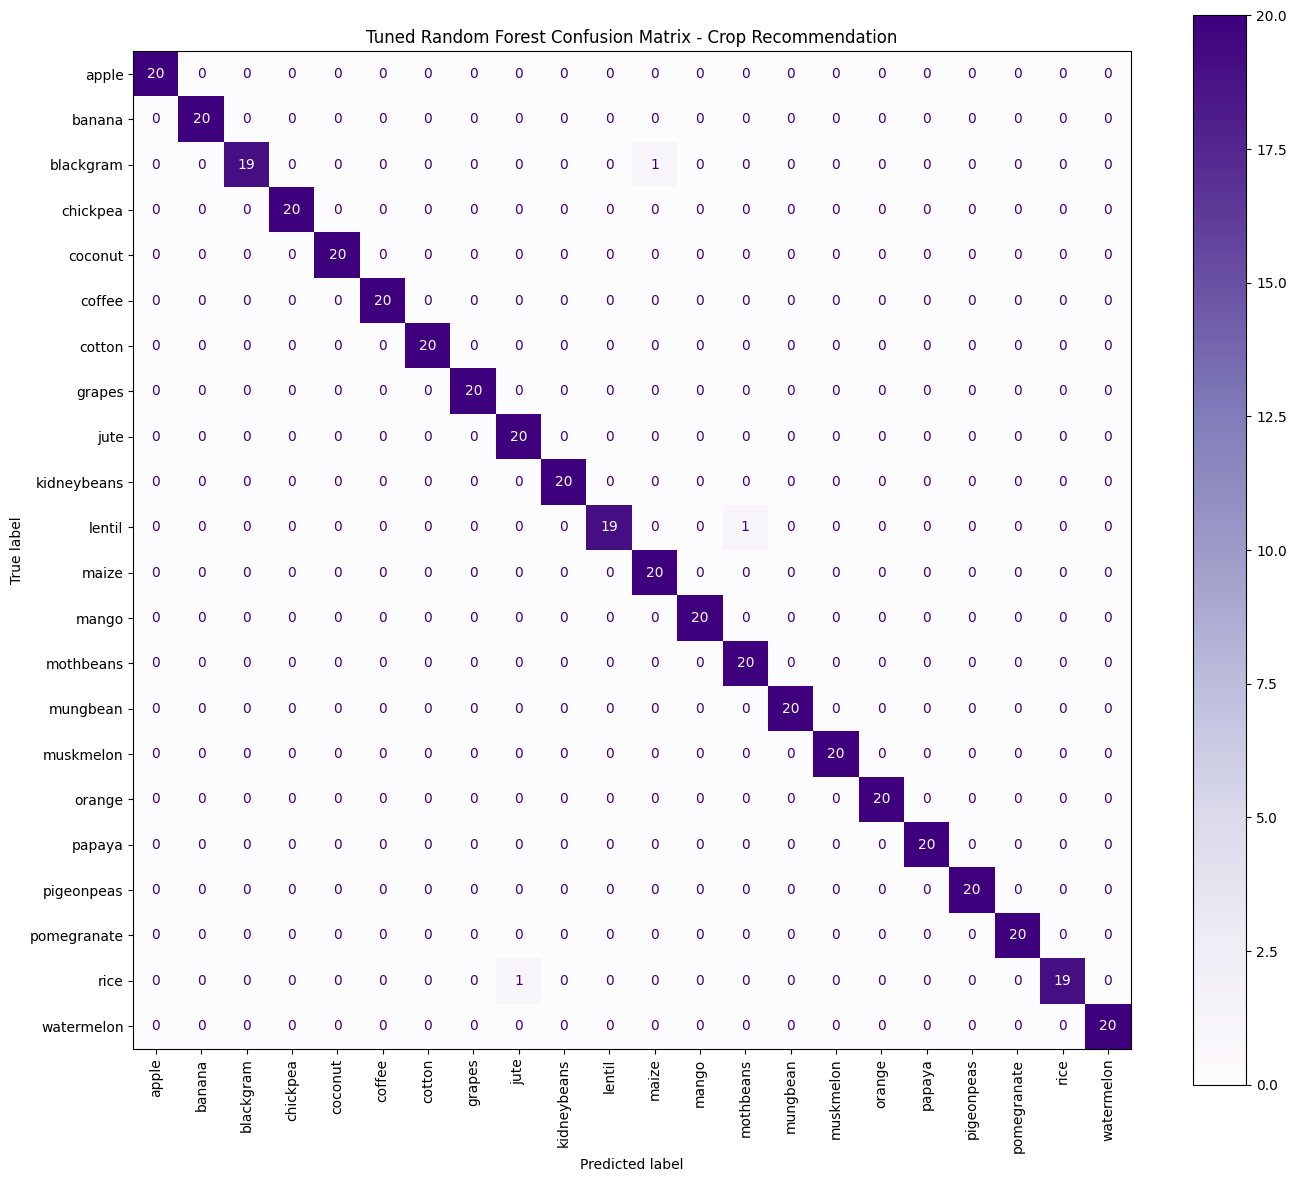

In [162]:
cm_tuned_rf = confusion_matrix(y_test, y_pred_best_rf)


disp_tuned_rf = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_rf, display_labels=best_rf_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))

# Keeping the 'Purples' colormap for consistency
disp_tuned_rf.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')

plt.title('Tuned Random Forest Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()


The tuned Random Forest confusion matrix is also almost perfectly diagonal, showing excellent classification performance with only a few isolated errors. Tuning does not materially change the error pattern, confirming that the default Random Forest was already very strong.


## 4.7 Comparing Tuned vs. Untuned Random Forest Model

Interestingly, the untuned Random Forest performs better than the tuned model. The discussion for why this might be is given in section 5.1.

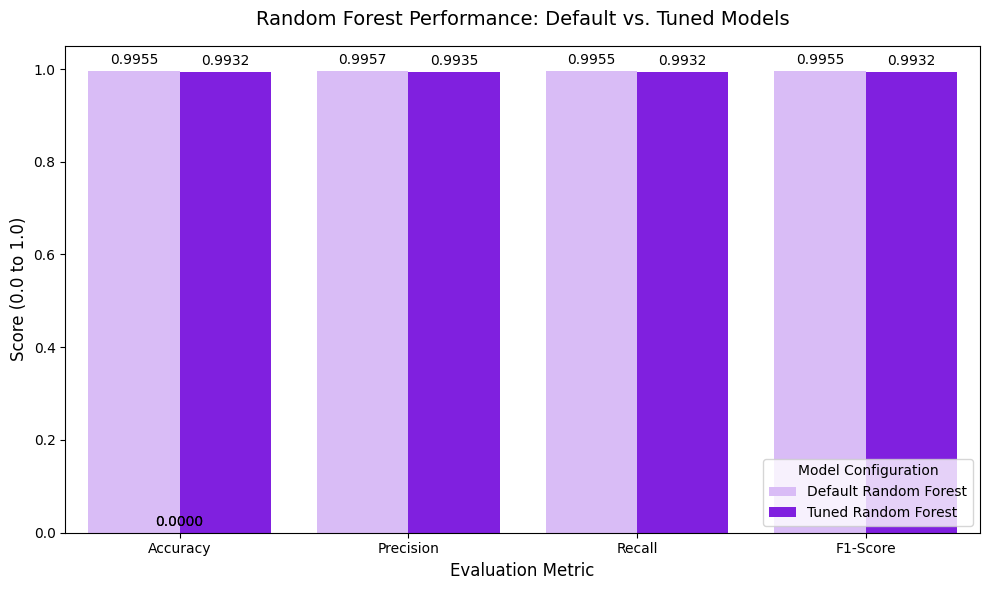

In [163]:
# Calculate metrics for both Random Forest versions
metrics_default_rf = get_metrics(y_test, y_pred_rf_untuned)
metrics_tuned_rf = get_metrics(y_test, y_pred_best_rf)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df_rf = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default_rf + metrics_tuned_rf,
    'Model': ['Default Random Forest'] * 4 + ['Tuned Random Forest'] * 4
})

# Plot the bar chart
plt.figure(figsize=(10, 6))

# Using a purple color palette to match your original Random Forest heatmap
sns.barplot(
    data=plot_df_rf,
    x='Metric',
    y='Score',
    hue='Model',
    palette=['#D9B3FF', '#8000FF'] # Light purple for default, bold purple for tuned
)

plt.title('Random Forest Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05)
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact decimal numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 8),
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()


The default Random Forest slightly outperforms the tuned version across all metrics, although the difference is very small. This suggests the baseline model was already near-optimal, and tuning did not lead to a meaningful improvement in generalization.

# 5.0 Comparing Logistic Regression, SVM, Decision Tree and Random Forest Models

For this comparison, we will take the best performing model (tuned or untuned) from each of the categories.

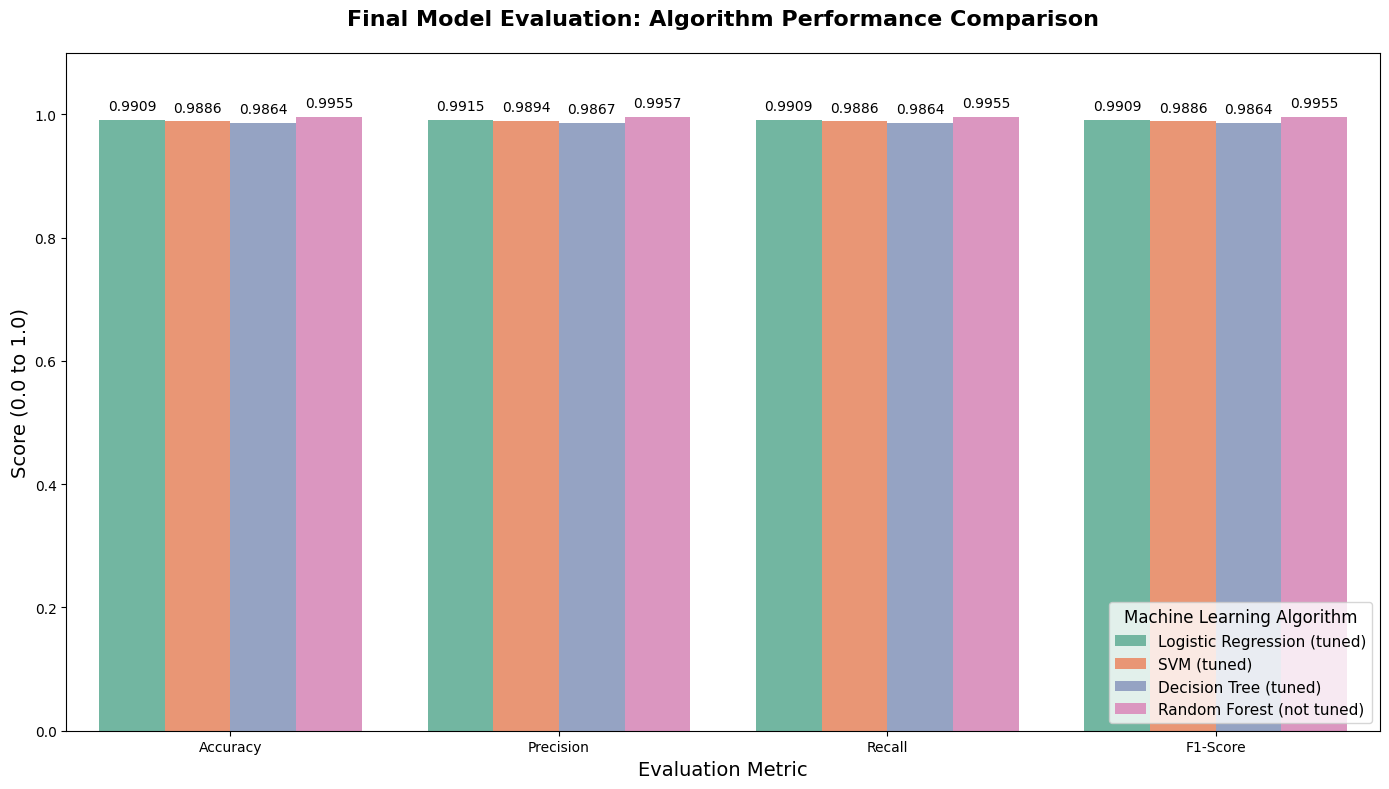

In [164]:
# These are the prediction variables from the best performing models:
# y_pred_tuned (Tuned Logistic Regression)
# y_pred_best_svm (Tuned SVM)
# y_pred_best_dt (Tuned Decision Tree)
# y_pred_rf_untuned (Default/Untuned Random Forest)

metrics_log = get_metrics(y_test, y_pred_tuned)
metrics_svm = get_metrics(y_test, y_pred_best_svm)
metrics_dt = get_metrics(y_test, y_pred_best_dt)
metrics_rf = get_metrics(y_test, y_pred_rf_untuned)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = ['Logistic Regression (tuned)', 'SVM (tuned)', 'Decision Tree (tuned)', 'Random Forest (not tuned)']

# Flatten the data into for seaborn
plot_data = []
all_metrics = [metrics_log, metrics_svm, metrics_dt, metrics_rf]

for model_idx, model_metrics in enumerate(all_metrics):
    for metric_idx, score in enumerate(model_metrics):
        plot_data.append({
            'Model': model_names[model_idx],
            'Metric': metrics_names[metric_idx],
            'Score': score
        })

plot_df_final = pd.DataFrame(plot_data)

# Plot the chart
# Making the figure slightly wider to comfortably fit 16 total bars
plt.figure(figsize=(14, 8))

# Using a distinct, professional color palette ('Set2' is great for presentations)
ax = sns.barplot(
    data=plot_df_final,
    x='Metric',
    y='Score',
    hue='Model',
    palette='Set2'
)

# Formatting the chart for usage in the report
plt.title('Final Model Evaluation: Algorithm Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.ylim(0.0, 1.1) # Extra headroom for labels and legend
plt.legend(title='Machine Learning Algorithm', title_fontsize='12', loc='lower right', fontsize='11')

# Add the exact decimal numbers on top of the bars, slightly rotated for readability
for p in ax.patches:
    # Skip rendering if the bar height is 0 (fixes the 0.000 matplotlib glitch)
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=10,
                    rotation=0)

plt.tight_layout()
plt.show()


In [165]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from IPython.display import display

# Choose RF variant for the table
use_tuned_rf = False  # set True to use tuned RF

if use_tuned_rf:
    rf_pred_for_table = y_pred_best_rf
    rf_tuned_label = "Yes"
    rf_cv_mean = grid_search_rf.best_score_
else:
    rf_pred_for_table = y_pred_rf_untuned
    rf_tuned_label = "No"
    rf_cv_mean = "N/A"  # no grid-search CV mean for untuned model

rows = [
    {
        "Model": "Logistic Regression",
        "Tuned?": "Yes",
        "Accuracy": accuracy_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred_tuned, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_pred_tuned, average="macro", zero_division=0),
        "CV Mean": grid_search.best_score_
    },
    {
        "Model": "SVM",
        "Tuned?": "Yes",
        "Accuracy": accuracy_score(y_test, y_pred_best_svm),
        "Precision": precision_score(y_test, y_pred_best_svm, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred_best_svm, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_pred_best_svm, average="macro", zero_division=0),
        "CV Mean": grid_search_svm.best_score_
    },
    {
        "Model": "Decision Tree",
        "Tuned?": "Yes",
        "Accuracy": accuracy_score(y_test, y_pred_best_dt),
        "Precision": precision_score(y_test, y_pred_best_dt, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred_best_dt, average="macro", zero_division=0),
        "F1": f1_score(y_test, y_pred_best_dt, average="macro", zero_division=0),
        "CV Mean": grid_search_dt.best_score_
    },
    {
        "Model": "Random Forest",
        "Tuned?": rf_tuned_label,
        "Accuracy": accuracy_score(y_test, rf_pred_for_table),
        "Precision": precision_score(y_test, rf_pred_for_table, average="macro", zero_division=0),
        "Recall": recall_score(y_test, rf_pred_for_table, average="macro", zero_division=0),
        "F1": f1_score(y_test, rf_pred_for_table, average="macro", zero_division=0),
        "CV Mean": rf_cv_mean
    }
]

comparison_df = pd.DataFrame(rows)

# Nice formatting without tabulate dependency
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    comparison_df[col] = comparison_df[col].map(lambda x: f"{x:.4f}")

comparison_df["CV Mean"] = comparison_df["CV Mean"].map(
    lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x
)

display(comparison_df)





,Model,Tuned?,Accuracy,Precision,Recall,F1,CV Mean
0,Logistic Regression,Yes,0.9909,0.9915,0.9909,0.9909,0.9824
1,SVM,Yes,0.9886,0.9894,0.9886,0.9886,0.9886
2,Decision Tree,Yes,0.9864,0.9867,0.9864,0.9864,0.9835
3,Random Forest,No,0.9955,0.9957,0.9955,0.9955,N/A


## 5.1 Discussion of Model Comparison Results
The final comparison shows that all four models performed extremely well, with accuracy and F1-scores above 0.98 in every case. This indicates that the crop recommendation dataset is highly learnable and that the selected features, including the engineered variables, provide strong predictive signal across model types.

The untuned Random Forest model is our best performing model across all metrics. The results suggest that Random Forest performed best for several reasons:

1. The Nature of Agricultural Data
To understand why Random Forest won, we have to look at the dataset itself. Crop data is highly non-linear and relies on strict environmental thresholds. For example, a crop might thrive if the temperature is between 20°C and 25°C, but fail completely if it drops to 19°C or jumps to 26°C.

- Logistic Regression (0.9909): This algorithm tries to draw straight lines (or planes) through the data. It struggles to capture those "goldilocks zones" (not too hot, not too cold) without complex feature transformations.

- Support Vector Machine (0.9886): While the RBF kernel helps SVMs handle non-linear data well by warping the geometric space, it still isn't quite as natural a fit for hard thresholds as a tree-based approach.

2. The Superiority of Ensembles
Decision Trees naturally excel at this kind of data because they literally mimic human rule-making (e.g., "Is rainfall > 100mm? If yes, go left. If no, go right.").

- Decision Tree (0.9864): The tuned single Decision Tree came in last place. Because a single tree is so prone to overfitting, our tuning process actively restricted its depth to force it to generalize. This pruning made it safer, but capped its raw accuracy.

- Random Forest (0.9955): The Random Forest takes 100 decision trees, gives them all a slightly different slice of the data, and lets them vote. This ensemble approach completely neutralizes the weaknesses of a single tree.

3. Why "Untuned" Beat "Tuned" in Random Forest
-Aggressive Default Settings: By default, scikit-learn sets max_depth=None. This allows the 100 trees in the forest to grow as deep and complex as they possibly can until every single leaf is perfectly pure.

- Clean Data: Usually, letting a model grow infinitely deep causes it to memorize noise and overfit. However, this specific curated Kaggle dataset is very clean and structured (it was very clean, even before we did any feature engineering). The default model's deeply grown trees were able to perfectly capture the ultra-specific, nuanced environmental niches for all 22 crops without "learning the wrong things."

- Tuning Acted as a Penalty: When we ran the Grid Search, it mathematically tried to protect the model from theoretical overfitting by restricting the tree depths and split rules. In this very specific case, those "safe" rules actually handcuffed the model slightly, causing it to misclassify a handful of edge-case crops that the complex, untuned model nailed.

In short: The default Random Forest is the perfect tool for the job. It leveraged the non-linear threshold nature of the weather and soil data, used the power of 100 voting trees to prevent individual errors, and benefited from being allowed to grow highly specific, unpruned rules.

## 5.2 Model Stability with Repeated Stratified CV

We used **Repeated Stratified Cross-Validation** to get a more reliable estimate of model performance than a single train/test split.

- **Stratified** means each fold preserves the class distribution of the full dataset.
- This is important because our task is **multiclass classification (22 crops)**, and each fold should contain a representative mix of classes.
- **Repeated** means we run stratified CV multiple times with different shuffles, reducing the chance that one lucky/unlucky split biases results.

### Benefits for this project

- Produces **more robust model comparison** across Logistic Regression, SVM, Decision Tree, and Random Forest.
- Reports both **mean performance** and **variability** (`mean +/- std`), not just one score.
- Improves confidence that the selected model (Random Forest) performs consistently, not only on one particular split.



In [166]:
# Repeated CV gives a more stable estimate than a single split
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

lr_best_params = grid_search.best_params_
svm_best_params = grid_search_svm.best_params_
dt_best_params = grid_search_dt.best_params_

models_for_cv = {
    'Logistic Regression (tuned)': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                C=lr_best_params['clf__C'],
                solver=lr_best_params['clf__solver'],
                max_iter=lr_best_params['clf__max_iter'],
                random_state=42
            ))
        ]
    ),
    'SVM (tuned)': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('clf', SVC(
                C=svm_best_params['clf__C'],
                gamma=svm_best_params['clf__gamma'],
                kernel=svm_best_params['clf__kernel'],
                random_state=42
            ))
        ]
    ),
    'Decision Tree (tuned)': DecisionTreeClassifier(**dt_best_params, random_state=42),
    'Random Forest (selected)': RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=1
    )
}

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_rows = []
for model_name, model in models_for_cv.items():
    cv_result = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({
        'Model': model_name,
        'accuracy_mean': cv_result['test_accuracy'].mean(),
        'accuracy_std': cv_result['test_accuracy'].std(),
        'precision_macro_mean': cv_result['test_precision_macro'].mean(),
        'precision_macro_std': cv_result['test_precision_macro'].std(),
        'recall_macro_mean': cv_result['test_recall_macro'].mean(),
        'recall_macro_std': cv_result['test_recall_macro'].std(),
        'f1_macro_mean': cv_result['test_f1_macro'].mean(),
        'f1_macro_std': cv_result['test_f1_macro'].std()
    })

cv_summary_df = pd.DataFrame(cv_rows).sort_values(by='accuracy_mean', ascending=False)

cv_display_df = cv_summary_df[['Model']].copy()
for metric in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']:
    cv_display_df[metric] = cv_summary_df.apply(
        lambda row: f"{row[f'{metric}_mean']:.4f} +/- {row[f'{metric}_std']:.4f}"
,
        axis=1
    )

cv_display_df


,Model,accuracy,precision_macro,recall_macro,f1_macro
3,Random Forest (selected),0.9935 +/- 0.0026,0.9939 +/- 0.0026,0.9935 +/- 0.0026,0.9935 +/- 0.0026
2,Decision Tree (tuned),0.9868 +/- 0.0063,0.9875 +/- 0.0062,0.9868 +/- 0.0063,0.9868 +/- 0.0064
1,SVM (tuned),0.9864 +/- 0.0029,0.9871 +/- 0.0029,0.9864 +/- 0.0029,0.9863 +/- 0.0029
0,Logistic Regression (tuned),0.9845 +/- 0.0040,0.9853 +/- 0.0040,0.9845 +/- 0.0040,0.9845 +/- 0.0041


### Interpretation of Repeated Stratified CV Results

These scores are shown as **mean +/- standard deviation** across repeated stratified folds.

- **Random Forest (selected)** is the best overall model:
  - Accuracy: **0.9935 +/- 0.0026**
  - Precision (macro): **0.9939 +/- 0.0026**
  - Recall (macro): **0.9935 +/- 0.0026**
  - F1 (macro): **0.9935 +/- 0.0026**
- It is not only the most accurate, but also the **most stable** (lowest variance).

- **Decision Tree (tuned)** has good mean performance, but higher variability:
  - Accuracy: **0.9868 +/- 0.0063**
- **SVM (tuned)** performs similarly to Decision Tree, with better stability:
  - Accuracy: **0.9864 +/- 0.0029**
- **Logistic Regression (tuned)** is the lowest performer of the four:
  - Accuracy: **0.9845 +/- 0.0040**

### What this means for model choice

- The Random Forest consistently generalizes best across different train/validation splits.
- The gap is small in absolute terms, but consistent across all macro metrics.
- This supports keeping **Random Forest** as the final model for deployment/reporting.


## 5.3 Error Analysis: Most Frequent Confusions
This section shows where the selected best model (Random Forest) still makes mistakes and surfaces example rows for inspection.


In [167]:
# Error analysis using the selected best model (Random Forest)
y_pred_best_overall = pd.Series(rf_model.predict(X_test), index=y_test.index, name='Predicted Label')

cm_best = confusion_matrix(y_test, y_pred_best_overall, labels=rf_model.classes_)
cm_df = pd.DataFrame(cm_best, index=rf_model.classes_, columns=rf_model.classes_)

confusion_rows = []
for true_label in cm_df.index:
    for pred_label in cm_df.columns:
        if true_label != pred_label:
            count = int(cm_df.loc[true_label, pred_label])
            if count > 0:
                confusion_rows.append({
                    'True Label': true_label,
                    'Predicted Label': pred_label,
                    'Count': count
                })

if confusion_rows:
    top_confusions_df = pd.DataFrame(confusion_rows).sort_values(by='Count', ascending=False).head(10)
    print('Top confusion pairs (non-zero only):')
    top_confusions_df
else:
    print('No misclassifications found for this model on the test split.')

misclassified_mask = y_test != y_pred_best_overall
misclassified_examples = X_test.loc[misclassified_mask].copy()
misclassified_examples['True Label'] = y_test.loc[misclassified_mask]
misclassified_examples['Predicted Label'] = y_pred_best_overall.loc[misclassified_mask]

print(f"Misclassified rows on test set: {misclassified_examples.shape[0]}")
misclassified_examples.head(10)


Top confusion pairs (non-zero only):
Misclassified rows on test set: 2


,N,P,K,temperature,humidity,ph,rainfall,moisture_index,P_to_K,ph_dev,True Label,Predicted Label
789,60,59,22,31.868473,66.742175,7.191523,74.222386,8.508105,2.681818,0.691523,blackgram,maize
83,67,43,39,26.043720,84.969072,5.999969,186.753677,9.672141,1.102564,0.500031,rice,jute


### Error Analysis Interpretation

This section provides a targeted review of the model’s residual errors on the holdout test set.

- **Top confusion pairs (non-zero only)**  
  This output identifies true-label/predicted-label class pairs where misclassifications occurred.  
  In this run, the confusion output is minimal, indicating that off-diagonal errors are very limited.

- **Misclassified rows on test set: 2**  
  The model produced only **2 incorrect predictions** on the test partition, which is consistent with the previously reported high performance metrics.

- **Misclassified sample table**  
  The displayed rows contain the full feature vectors of the misclassified observations.  
  These cases represent high-value diagnostic examples for understanding boundary ambiguity between agronomically similar crop classes.

### Practical Implication

The error profile is both **low in frequency** and **narrow in scope**, suggesting strong generalization on this dataset.  
At the same time, preserving and reviewing these edge cases is important for model governance, interpretability, and future robustness improvements.



# 6.0 Multiclass Classification: Top Three Crops Suggestions

Given what we already know about our data and the performance of various machine learning algorithms on it, we would next like to tackle a similar but a bit more challenging problem: 

> **Given the features we have, can we build a recommendation system that suggests the top three best fitting crops?**

The output of this model will be 3 different crops, in descending order of how well they suit the given features.

## 6.1 Methodology

From our previous findings we know that the untuned 'Random Forest' model is the best performing machine learning algorithm (out of the ones we trained) on our dataset. Thus, we will be using the untuned 'Random Forest' for this task.

We will be determining the top three best crops for each row of data based on the probability scores assigned to the labels by the 'Random Forest' model. The reason we are doing this is because the dataset we are using is multiclass (there is exactly one true answer for each row of data), not multilabel (where there are multiple correct answers to each row of data). Therefore, we will be asking the model: *"We know there is only one correct answer but what is your 1st choice, 2nd choice, and 3rd choice based on your probability scores?".* 


## 6.2 Defining the Top Three Recommendations Function 

In [171]:
# rf_model is the untuned (default) Random Forest model we trained earlier

def get_top_3_recommendations(model, input_features):
    """
    Takes a trained model and a dataframe of features.
    Returns the top 3 predicted crops and their confidence scores.
    """
    # Get the probability matrix (rows = data points, columns = the 22 crops)
    probabilities = model.predict_proba(input_features)
    
    # Extract the actual names of the crops from the model
    crop_classes = model.classes_
    
    results = []
    
    # Loop through the probabilities for each row of data
    for prob_array in probabilities:
        # np.argsort sorts from lowest to highest. 
        # [-3:] grabs the last 3 (the highest).
        # [::-1] flips them so the very highest is first.
        top_3_indices = np.argsort(prob_array)[-3:][::-1]
        
        # Match the indices back to the crop names and their percentage scores
        top_3_crops = [
            (crop_classes[i], prob_array[i] * 100) for i in top_3_indices
        ]
        results.append(top_3_crops)
        
    return results

## 6.3 Testing the Results

Here, we test the results on the first 5 rows of our data, and then on ten random rows from our data.

In [169]:
# Let's test it out on the first 5 rows of our testing data
sample_data = X_test.head(5)
top_3_output = get_top_3_recommendations(rf_model, sample_data)

# Print the results in a readable format
print("Top 3 Crop Recommendations for the First 5 Rows of the Dataset:\n")
for i, recommendations in enumerate(top_3_output):
    print(f"Plot {i + 1} Conditions:")
    for rank, (crop, confidence) in enumerate(recommendations, 1):
        print(f"  {rank}. {crop.capitalize()} (Confidence: {confidence:.4f}%)")
    print("-" * 30)

# Let's test it out on 10 random rows of our testing data
# Get random sample data
random_sample_data = X_test.sample(n=10, random_state=42) #changing 42 will give differet results each time

# Get the top 3 predictions for these 10 random plots
top_3_output_random = get_top_3_recommendations(rf_model, random_sample_data)

# Print the results in a readable format
print("\n")
print("-" * 30)
print("Top 3 Crop Recommendations for 10 Random Plots:\n")
for i, recommendations in enumerate(top_3_output_random):
    print(f"Random Plot {i + 1}:")
    for rank, (crop, confidence) in enumerate(recommendations, 1):
        print(f"  {rank}. {crop.capitalize()} (Confidence: {confidence:.4f}%)")
    print("-" * 30)

Top 3 Crop Recommendations for the First 5 Rows of the Dataset:

Plot 1 Conditions:
  1. Orange (Confidence: 100.0000%)
  2. Watermelon (Confidence: 0.0000%)
  3. Rice (Confidence: 0.0000%)
------------------------------
Plot 2 Conditions:
  1. Banana (Confidence: 100.0000%)
  2. Watermelon (Confidence: 0.0000%)
  3. Pomegranate (Confidence: 0.0000%)
------------------------------
Plot 3 Conditions:
  1. Cotton (Confidence: 97.0000%)
  2. Maize (Confidence: 3.0000%)
  3. Pomegranate (Confidence: 0.0000%)
------------------------------
Plot 4 Conditions:
  1. Maize (Confidence: 99.0000%)
  2. Cotton (Confidence: 1.0000%)
  3. Pomegranate (Confidence: 0.0000%)
------------------------------
Plot 5 Conditions:
  1. Orange (Confidence: 99.0000%)
  2. Pomegranate (Confidence: 1.0000%)
  3. Rice (Confidence: 0.0000%)
------------------------------


------------------------------
Top 3 Crop Recommendations for 10 Random Plots:

Random Plot 1:
  1. Mothbeans (Confidence: 94.0000%)
  2. Lentil

## 6.4 Calculating the Top 3 Accuracy

In [170]:
# Get the probability matrix for the test set
# (We need the raw percentages for all 22 crops, not just the final prediction)
y_prob_rf = rf_model.predict_proba(X_test)

# Calculate Top-3 Accuracy
# k=3 tells the function to check the top 3 highest probabilities
# labels=rf_model.classes_ ensures the math maps correctly to your 22 crop names
top3_acc = top_k_accuracy_score(y_test, y_prob_rf, k=3, labels=rf_model.classes_)

print(f"Standard Accuracy (Top-1): {accuracy_score(y_test, rf_model.predict(X_test)) * 100:.4f}%")
print(f"Top-3 Accuracy: {top3_acc * 100:.4f}%")

Standard Accuracy (Top-1): 99.5455%
Top-3 Accuracy: 100.0000%




### 6.5 Discussion of Top-3 Results

The Top-3 evaluation shows that, on the holdout test set, the correct crop recommendation always appeared within the model’s top three predicted probabilities. This suggests that the Random Forest performs well not only as a strict multi-class classifier, but also as a practical decision-support tool.

This result is especially relevant in an agricultural context, where recommending a small set of suitable crop options may be more realistic than forcing a single final prediction. In practice, farmers may also consider other factors not captured in the dataset, such as market prices, local constraints, costs, and personal preferences. For that reason, a Top-3 recommendation framework can provide more flexible and useful guidance than a Top-1 prediction alone.

At the same time, this result should be interpreted carefully. The 100% Top-3 score applies to this test set and does not guarantee the same performance in all real-world settings. Still, it provides strong evidence that the model is highly effective at narrowing down the most plausible crop choices.